In [ ]:
import pandas as pd
train_dataset = pd.read_csv("/content/train_dataset.csv")
test_dataset = pd.read_csv("/content/test_dataset.csv")

In [ ]:
pip install pandas numpy scikit-learn gensim xgboost matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 21.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1,2),   # 1-gram + 2-gram 捕获短语情感
    stop_words="english"
)

In [ ]:
def map_label(x):
    x = str(x).lower()
    if "negative" in x or x == "-1":
        return 2
    elif "positive" in x or x == "1":
        return 1
    else:
        return 0

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ======================
# 1. 标签映射函数
# ======================
def map_label(x):
    x = str(x).lower()
    if "negative" in x or x == "-1":
        return 2
    elif "positive" in x or x == "1":
        return 1
    else:
        return 0

# ======================
# 2. 加载你的 train / test 数据集（直接使用）
# ======================
# 请确保你的 train_dataset 和 test_dataset 已经是 pandas DataFrame
# 包含列：text（文本）、text_sentiment（情感标签）

# 处理训练集
train_dataset_X = train_dataset["text"].astype(str)
train_dataset_y = train_dataset["text_sentiment"].apply(map_label).values

# 处理测试集
test_dataset_X = test_dataset["text"].astype(str)
test_dataset_y = test_dataset["text_sentiment"].apply(map_label).values

# ======================
# 3. TF-IDF 文本向量化
# ======================
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

# 只在训练集上 fit，测试集只 transform（正确做法）
X_train_vec = tfidf.fit_transform(train_dataset_X).toarray()
X_test_vec = tfidf.transform(test_dataset_X).toarray()

# ======================
# 4. 训练模型
# ======================
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, train_dataset_y)

# ======================
# 5. 预测 & 评估
# ======================
y_pred = model.predict(X_test_vec)

print("=" * 50)
print("模型评估结果")
print("=" * 50)
print("准确率 (Accuracy):", accuracy_score(test_dataset_y, y_pred))
print("\n分类报告:\n")
print(classification_report(test_dataset_y, y_pred))

模型评估结果
准确率 (Accuracy): 0.5766666666666667

分类报告:

              precision    recall  f1-score   support

           0       0.63      0.67      0.65       100
           1       0.60      0.52      0.56       100
           2       0.51      0.54      0.52       100

    accuracy                           0.58       300
   macro avg       0.58      0.58      0.58       300
weighted avg       0.58      0.58      0.58       300



Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:54:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



最优参数：
{'learning_rate': 0.15, 'max_depth': 6, 'n_estimators': 50, 'subsample': 0.8}

           模型评估（TF-IDF + XGBoost 三分类）
准确率: 0.5467

分类报告:
              precision    recall  f1-score   support

           0      0.531     0.430     0.475       100
           1      0.517     0.900     0.657       100
           2      0.689     0.310     0.428       100

    accuracy                          0.547       300
   macro avg      0.579     0.547     0.520       300
weighted avg      0.579     0.547     0.520       300



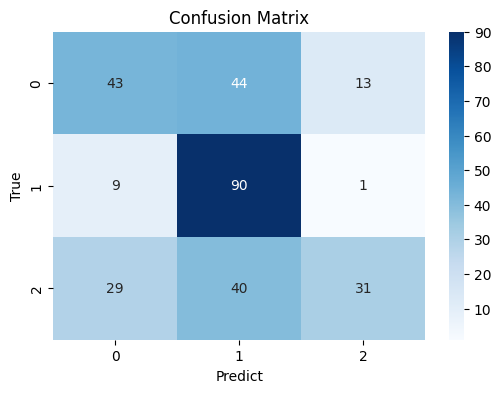


模型保存完成！


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 纯原生库，无任何 TensorFlow
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ======================
# 1. 三分类标签映射
# ======================
def map_label(x):
    x = str(x).lower()
    if "negative" in x or x == "-1":
        return 0
    elif "neutral" in x or x == "0":
        return 1
    elif "positive" in x or x == "1":
        return 2
    else:
        return 1  # 默认归为中性

# ======================
# 2. 直接使用你的训练集 & 测试集
# ======================
# 训练数据
train_text = train_dataset["text"].astype(str)
train_label = train_dataset["text_sentiment"].apply(map_label).values

# 测试数据
test_text = test_dataset["text"].astype(str)
test_label = test_dataset["text_sentiment"].apply(map_label).values

# ======================
# 3. TF-IDF 文本向量化
# ======================
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

# 训练集：fit + transform
# 测试集：只 transform
X_train_vec = tfidf.fit_transform(train_text)
X_test_vec = tfidf.transform(test_text)

# ======================
# 4. 原生 XGBoost + 网格搜索（3分类）
# ======================
model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",
    use_label_encoder=False,
    objective="multi:softmax",
    num_class=3
)

param_grid = {
    'n_estimators': [50, 100, 200, 250],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.05, 0.1,0.15],
    'subsample': [0.8]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

# 训练
grid.fit(X_train_vec, train_label)
best_model = grid.best_estimator_

print("\n最优参数：")
print(grid.best_params_)

# ======================
# 5. 模型评估
# ======================
y_pred = best_model.predict(X_test_vec)

print("\n" + "="*60)
print("           模型评估（TF-IDF + XGBoost 三分类）")
print("="*60)
print(f"准确率: {accuracy_score(test_label, y_pred):.4f}")
print("\n分类报告:")
print(classification_report(test_label, y_pred, digits=3))

# 混淆矩阵
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(test_label, y_pred), annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("True")
plt.show()

# ======================
# 6. 保存模型
# ======================
joblib.dump(best_model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("\n模型保存完成！")

Fitting 5 folds for each of 27 candidates, totalling 135 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:00:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



最优参数：
{'learning_rate': 0.15, 'max_depth': 6, 'n_estimators': 50, 'subsample': 0.8}

           模型评估（TF-IDF + XGBoost 三分类）
准确率: 0.5467

分类报告:
              precision    recall  f1-score   support

           0      0.531     0.430     0.475       100
           1      0.517     0.900     0.657       100
           2      0.689     0.310     0.428       100

    accuracy                          0.547       300
   macro avg      0.579     0.547     0.520       300
weighted avg      0.579     0.547     0.520       300



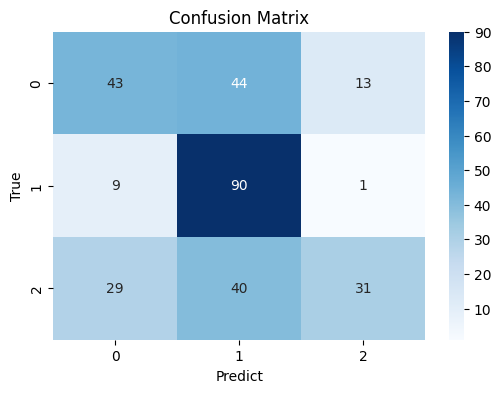


模型保存完成！


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 纯原生库，无任何 TensorFlow
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ======================
# 1. 三分类标签映射
# ======================
def map_label(x):
    x = str(x).lower()
    if "negative" in x or x == "-1":
        return 0
    elif "neutral" in x or x == "0":
        return 1
    elif "positive" in x or x == "1":
        return 2
    else:
        return 1  # 默认归为中性

# ======================
# 2. 直接使用你的训练集 & 测试集
# ======================
# 训练数据
train_text = train_dataset["text"].astype(str)
train_label = train_dataset["text_sentiment"].apply(map_label).values

# 测试数据
test_text = test_dataset["text"].astype(str)
test_label = test_dataset["text_sentiment"].apply(map_label).values

# ======================
# 3. TF-IDF 文本向量化
# ======================
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

# 训练集：fit + transform
# 测试集：只 transform
X_train_vec = tfidf.fit_transform(train_text)
X_test_vec = tfidf.transform(test_text)

# ======================
# 4. 原生 XGBoost + 网格搜索（3分类）
# ======================
model = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss",
    use_label_encoder=False,
    objective="multi:softmax",
    num_class=3
)

param_grid = {
    'n_estimators': [50, 75, 100,],
    'max_depth': [5, 6, 7],
    'learning_rate': [0.1,0.15,0.2],
    'subsample': [0.8]
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

# 训练
grid.fit(X_train_vec, train_label)
best_model = grid.best_estimator_

print("\n最优参数：")
print(grid.best_params_)

# ======================
# 5. 模型评估
# ======================
y_pred = best_model.predict(X_test_vec)

print("\n" + "="*60)
print("           模型评估（TF-IDF + XGBoost 三分类）")
print("="*60)
print(f"准确率: {accuracy_score(test_label, y_pred):.4f}")
print("\n分类报告:")
print(classification_report(test_label, y_pred, digits=3))

# 混淆矩阵
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(test_label, y_pred), annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("True")
plt.show()

# ======================
# 6. 保存模型
# ======================
joblib.dump(best_model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("\n模型保存完成！")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

最优参数：
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}

        模型评估（TF-IDF + 随机森林 三分类）
准确率: 0.5767

分类报告:
              precision    recall  f1-score   support

           0      0.566     0.470     0.514       100
           1      0.547     0.870     0.672       100
           2      0.672     0.390     0.494       100

    accuracy                          0.577       300
   macro avg      0.595     0.577     0.560       300
weighted avg      0.595     0.577     0.560       300



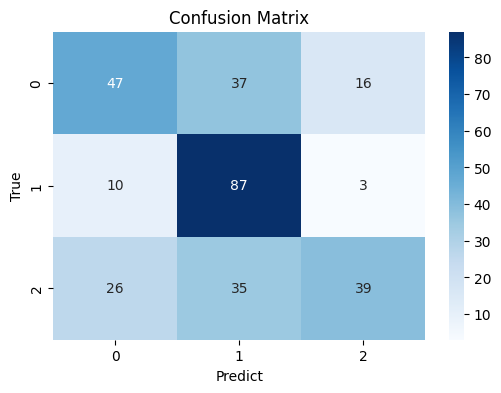


模型保存完成！


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 纯原生库，无任何 TensorFlow
from sklearn.ensemble import RandomForestClassifier  # 随机森林
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ======================
# 1. 三分类标签映射
# ======================
def map_label(x):
    x = str(x).lower()
    if "negative" in x or x == "-1":
        return 0
    elif "neutral" in x or x == "0":
        return 1
    elif "positive" in x or x == "1":
        return 2
    else:
        return 1  # 默认归为中性

# ======================
# 2. 直接使用你的训练集 & 测试集
# ======================
# 训练数据
train_text = train_dataset["text"].astype(str)
train_label = train_dataset["text_sentiment"].apply(map_label).values

# 测试数据
test_text = test_dataset["text"].astype(str)
test_label = test_dataset["text_sentiment"].apply(map_label).values

# ======================
# 3. TF-IDF 文本向量化
# ======================
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

# 训练集：fit + transform
# 测试集：只 transform
X_train_vec = tfidf.fit_transform(train_text)
X_test_vec = tfidf.transform(test_text)

# ======================
# 4. 随机森林 + 网格搜索（3分类专用）
# ======================
# 替换为随机森林
model = RandomForestClassifier(random_state=42)

# 随机森林调参范围
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 网格搜索
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

# 训练
grid.fit(X_train_vec, train_label)
best_model = grid.best_estimator_

print("\n最优参数：")
print(grid.best_params_)

# ======================
# 5. 模型评估
# ======================
y_pred = best_model.predict(X_test_vec)

print("\n" + "="*60)
print("        模型评估（TF-IDF + 随机森林 三分类）")
print("="*60)
print(f"准确率: {accuracy_score(test_label, y_pred):.4f}")
print("\n分类报告:")
print(classification_report(test_label, y_pred, digits=3))

# 混淆矩阵
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(test_label, y_pred), annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("True")
plt.show()

# ======================
# 6. 保存模型
# ======================
joblib.dump(best_model, "rf_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("\n模型保存完成！")

Fitting 5 folds for each of 54 candidates, totalling 270 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
90 fits failed out of a total of 270.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/


最优参数：
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 75}

        模型评估（TF-IDF + 随机森林 三分类）
准确率: 0.5667

分类报告:
              precision    recall  f1-score   support

           0      0.537     0.430     0.478       100
           1      0.549     0.890     0.679       100
           2      0.655     0.380     0.481       100

    accuracy                          0.567       300
   macro avg      0.581     0.567     0.546       300
weighted avg      0.581     0.567     0.546       300



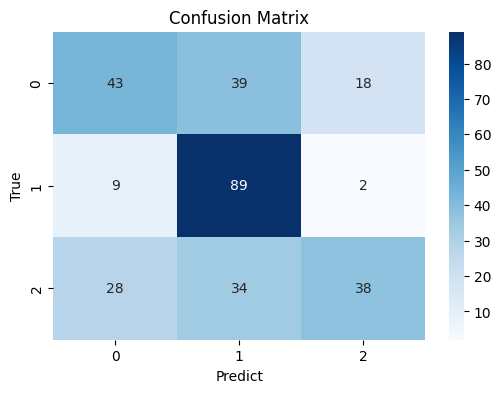


模型保存完成！


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 纯原生库，无任何 TensorFlow
from sklearn.ensemble import RandomForestClassifier  # 随机森林
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ======================
# 1. 三分类标签映射
# ======================
def map_label(x):
    x = str(x).lower()
    if "negative" in x or x == "-1":
        return 0
    elif "neutral" in x or x == "0":
        return 1
    elif "positive" in x or x == "1":
        return 2
    else:
        return 1  # 默认归为中性

# ======================
# 2. 直接使用你的训练集 & 测试集
# ======================
# 训练数据
train_text = train_dataset["text"].astype(str)
train_label = train_dataset["text_sentiment"].apply(map_label).values

# 测试数据
test_text = test_dataset["text"].astype(str)
test_label = test_dataset["text_sentiment"].apply(map_label).values

# ======================
# 3. TF-IDF 文本向量化
# ======================
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

# 训练集：fit + transform
# 测试集：只 transform
X_train_vec = tfidf.fit_transform(train_text)
X_test_vec = tfidf.transform(test_text)

# ======================
# 4. 随机森林 + 网格搜索（3分类专用）
# ======================
# 替换为随机森林
model = RandomForestClassifier(random_state=42)

# 随机森林调参范围
param_grid = {
    'n_estimators': [50, 75, 25],
    'max_depth': [10, 5, None],
    'min_samples_split': [1, 2, 3],
    'min_samples_leaf': [2, 3]
}

# 网格搜索
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

# 训练
grid.fit(X_train_vec, train_label)
best_model = grid.best_estimator_

print("\n最优参数：")
print(grid.best_params_)

# ======================
# 5. 模型评估
# ======================
y_pred = best_model.predict(X_test_vec)

print("\n" + "="*60)
print("        模型评估（TF-IDF + 随机森林 三分类）")
print("="*60)
print(f"准确率: {accuracy_score(test_label, y_pred):.4f}")
print("\n分类报告:")
print(classification_report(test_label, y_pred, digits=3))

# 混淆矩阵
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(test_label, y_pred), annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("True")
plt.show()

# ======================
# 6. 保存模型
# ======================
joblib.dump(best_model, "rf_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("\n模型保存完成！")

Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.0936


Epoch,Training Loss,Validation Loss
1,0.971248,0.909736
2,0.750812,0.790479
3,0.598576,0.760355
4,0.544942,0.764069



              BERT 直接三分类结果
准确率: 0.6833

分类报告:
              precision    recall  f1-score   support

      负面(-1)      0.670     0.770     0.716       100
       中性(0)      0.768     0.630     0.692       100
       正面(1)      0.631     0.650     0.640       100

    accuracy                          0.683       300
   macro avg      0.690     0.683     0.683       300
weighted avg      0.690     0.683     0.683       300



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missi

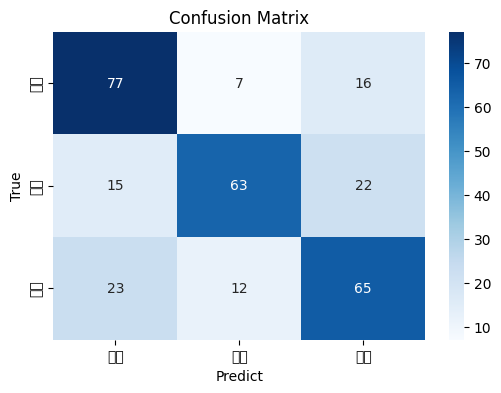


✅ 三分类模型训练完成 & 保存成功！


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 配置
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
NUM_LABELS = 3  # 直接三分类！

# ======================
# 加载你的训练集 & 测试集
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

# 标签映射：-1→0(负面)，0→1(中性)，1→2(正面)
def map_label(x):
    return int(x) + 1  # 最关键：直接变成 0,1,2 三分类

train_df["label"] = train_df["text_sentiment"].apply(map_label)
test_df["label"] = test_df["text_sentiment"].apply(map_label)

# 构建 HuggingFace 数据集
ds_train = Dataset.from_pandas(train_df[["text", "label"]])
ds_test = Dataset.from_pandas(test_df[["text", "label"]])

# ======================
# Tokenizer
# ======================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN
    )

ds_train_enc = ds_train.map(tokenize_func, batched=True)
ds_test_enc = ds_test.map(tokenize_func, batched=True)

# ======================
# LoRA 模型（直接3分类）
# ======================
def get_lora_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS  # 3分类
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        target_modules=["q_lin", "v_lin"]
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model

# ======================
# 训练参数
# ======================
args = TrainingArguments(
    output_dir="./bert_3class",
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    fp16=False
)

# ======================
# 训练
# ======================
model = get_lora_model()
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train_enc,
    eval_dataset=ds_test_enc,
    data_collator=data_collator
)

# 开始训练
trainer.train()

# ======================
# 预测 & 评估
# ======================
preds = trainer.predict(ds_test_enc)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

# 还原标签：0→-1，1→0，2→1
y_true = y_true - 1
y_pred = y_pred - 1

# 输出结果
print("\n" + "="*60)
print("              BERT 直接三分类结果")
print("="*60)
print(f"准确率: {accuracy_score(y_true, y_pred):.4f}")
print("\n分类报告:")
print(classification_report(
    y_true, y_pred,
    target_names=["负面(-1)", "中性(0)", "正面(1)"],
    digits=3
))

# 混淆矩阵
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["负面","中性","正面"],
            yticklabels=["负面","中性","正面"])
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("True")
plt.show()

# ======================
# 保存模型
# ======================
model.save_pretrained("bert_3class_final")
tokenizer.save_pretrained("bert_3class_tokenizer")
print("\n✅ 三分类模型训练完成 & 保存成功！")

In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# ======================
# 全局配置
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
RANDOM_STATE = 42

# ======================
# 直接使用你的 train_dataset 和 test_dataset
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

# 标签映射
train_df["original_label"] = train_df["text_sentiment"].astype(int)
test_df["original_label"] = test_df["text_sentiment"].astype(int)

# ==============================================================================
# TF-IDF 特征（正常保留）
# ==============================================================================
tfidf = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1,2))
train_tfidf = tfidf.fit_transform(train_df["text"].astype(str)).toarray()
test_tfidf = tfidf.transform(test_df["text"].astype(str)).toarray()

# ======================
# 1. 第一级模型：中性 vs 非中性
# ======================
train_df["stage1_label"] = train_df["original_label"].apply(lambda x: 0 if x == 0 else 1)
test_df["stage1_label"] = test_df["original_label"].apply(lambda x: 0 if x == 0 else 1)

def build_dataset(X, y):
    return Dataset.from_pandas(pd.DataFrame({"text": X, "label": y}))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LEN)

# ======================
# LoRA 模型
# ======================
def get_lora_model(num_labels):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels, torch_dtype=torch.float32
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
        target_modules=["q_lin", "v_lin"]
    )
    model = get_peft_model(model, lora_config)
    return model

# ======================
# 训练函数
# ======================
def train_model(train_dataset, eval_dataset, num_labels, output_dir):
    model = get_lora_model(num_labels)
    train_dataset = train_dataset.map(tokenize_func, batched=True)
    eval_dataset = eval_dataset.map(tokenize_func, batched=True)

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=2e-4,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=10,
        fp16=False  # 只保留这个，删掉 no_cuda
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator
    )
    trainer.train()
    return trainer, model

# 训练第一级
train1, model1 = train_model(
    build_dataset(train_df["text"], train_df["stage1_label"]),
    build_dataset(test_df["text"], test_df["stage1_label"]),
    num_labels=2, output_dir="./lora_stage1"
)

# 评估第一级
pred1 = train1.predict(build_dataset(test_df["text"], test_df["stage1_label"]).map(tokenize_func, batched=True))
p1 = np.argmax(pred1.predictions, axis=1)
l1 = pred1.label_ids

print("="*60)
print("           第一级模型：中性 vs 非中性")
print("="*60)
print(f"准确率: {accuracy_score(l1, p1):.4f}")
print(classification_report(l1, p1, target_names=["中性","非中性"], digits=3))

# ======================
# 2. 第二级模型：负面 vs 正面
# ======================
train2 = train_df[train_df["original_label"] != 0].copy()
test2 = test_df[test_df["original_label"] != 0].copy()

train2["stage2_label"] = train2["original_label"].map({-1:0, 1:1})
test2["stage2_label"] = test2["original_label"].map({-1:0, 1:1})

train2, model2 = train_model(
    build_dataset(train2["text"], train2["stage2_label"]),
    build_dataset(test2["text"], test2["stage2_label"]),
    num_labels=2, output_dir="./lora_stage2"
)

# 评估第二级
pred2 = train2.predict(build_dataset(test2["text"], test2["stage2_label"]).map(tokenize_func, batched=True))
p2 = np.argmax(pred2.predictions, axis=1)
l2 = pred2.label_ids

print("\n" + "="*60)
print("           第二级模型：负面 vs 正面")
print("="*60)
print(f"准确率: {accuracy_score(l2, p2):.4f}")
print(classification_report(l2, p2, target_names=["负面","正面"], digits=3))

# ======================
# 3. 两级联合预测（修复设备问题）
# ======================
def predict_two_stage(text):
    inputs = tokenizer(
        text, truncation=True, max_length=MAX_LEN, return_tensors="pt"
    )

    # 核心修复：自动匹配模型设备
    device = next(model1.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out1 = model1(**inputs)
    is_neutral = torch.argmax(out1.logits).item()

    if is_neutral == 0:
        return 0

    with torch.no_grad():
        out2 = model2(**inputs)
    sent = torch.argmax(out2.logits).item()
    return -1 if sent == 0 else 1

# 测试集评估
test_df["pred"] = test_df["text"].apply(predict_two_stage)
y_true = test_df["original_label"]
y_pred = test_df["pred"]

print("\n" + "="*60)
print("        🚀 两级模型最终 3分类 评估结果")
print("="*60)
print(f"最终准确率: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(
    y_true, y_pred,
    target_names=["负面","中性","正面"],
    digits=3
))

# ======================
# 保存模型
# ======================
model1.save_pretrained("lora_stage1_neutral")
model2.save_pretrained("lora_stage2_sentiment")
tokenizer.save_pretrained("lora_two_stage")

import joblib
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("\n✅ 所有错误已修复！运行成功！")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.584332,0.489703
2,0.368450,0.480345
3,0.353595,0.488541


...

Map:   0%|          | 0/672 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.719724,0.666449
2,0.550894,0.564748
3,0.505046,0.524249


Map:   0%|          | 0/200 [00:00<?, ? examples/s]


           第二级模型：负面 vs 正面
准确率: 0.7450
              precision    recall  f1-score   support

          负面      0.713     0.820     0.763       100
          正面      0.788     0.670     0.724       100

    accuracy                          0.745       200
   macro avg      0.751     0.745     0.744       200
weighted avg      0.751     0.745     0.744       200


        🚀 两级模型最终 3分类 评估结果
最终准确率: 0.6233
              precision    recall  f1-score   support

          负面      0.593     0.700     0.642       100
          中性      0.660     0.660     0.660       100
          正面      0.622     0.510     0.560       100

    accuracy                          0.623       300
   macro avg      0.625     0.623     0.621       300
weighted avg      0.625     0.623     0.621       300


✅ 所有错误已修复！运行成功！


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# ======================
# 全局配置
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
RANDOM_STATE = 42

# ======================
# 直接使用你的 train_dataset & test_dataset
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

train_df["original_label"] = train_df["text_sentiment"].astype(int)
test_df["original_label"] = test_df["text_sentiment"].astype(int)

# ==============================================================================
# TF-IDF 特征（共存）
# ==============================================================================
tfidf = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1,2))
train_tfidf = tfidf.fit_transform(train_df["text"].astype(str)).toarray()
test_tfidf = tfidf.transform(test_df["text"].astype(str)).toarray()

# ======================
# 🔥 第一级：先判断 正面(1) vs 非正面(0/1→0)
# ======================
train_df["stage1_label"] = train_df["original_label"].apply(lambda x: 1 if x == 1 else 0)
test_df["stage1_label"] = test_df["original_label"].apply(lambda x: 1 if x == 1 else 0)

def build_dataset(X, y):
    return Dataset.from_pandas(pd.DataFrame({"text": X, "label": y}))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LEN)

def get_lora_model(num_labels):
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
        target_modules=["q_lin", "v_lin"]
    )
    model = get_peft_model(model, lora_config)
    return model

def train_model(train_dataset, eval_dataset, num_labels, output_dir):
    model = get_lora_model(num_labels)
    train_dataset = train_dataset.map(tokenize_func, batched=True)
    eval_dataset = eval_dataset.map(tokenize_func, batched=True)

    args = TrainingArguments(
        output_dir=output_dir, num_train_epochs=3, per_device_train_batch_size=8,
        per_device_eval_batch_size=8, learning_rate=2e-4, weight_decay=0.01,
        eval_strategy="epoch", save_strategy="epoch", load_best_model_at_end=True, logging_steps=10,
        fp16=False
    )

    trainer = Trainer(
        model=model, args=args, train_dataset=train_dataset, eval_dataset=eval_dataset,
        data_collator=data_collator
    )
    trainer.train()
    return trainer, model

# 训练第一级：正面 vs 非正面
trainer1, model1 = train_model(
    build_dataset(train_df["text"], train_df["stage1_label"]),
    build_dataset(test_df["text"], test_df["stage1_label"]),
    num_labels=2, output_dir="./lora_stage1_positive"
)

# 评估第一级
pred1 = trainer1.predict(build_dataset(test_df["text"], test_df["stage1_label"]).map(tokenize_func, batched=True))
p1 = np.argmax(pred1.predictions, axis=1)
l1 = pred1.label_ids

print("="*60)
print("           第一级：正面 vs 非正面")
print("="*60)
print(f"准确率: {accuracy_score(l1, p1):.4f}")
print(classification_report(l1, p1, target_names=["非正面","正面"], digits=3))

# ======================
# 🔥 第二级：只训练非正面 → 中性(0) vs 负面(-1)
# ======================
train2 = train_df[train_df["original_label"] != 1].copy()
test2 = test_df[test_df["original_label"] != 1].copy()

train2["stage2_label"] = train2["original_label"].apply(lambda x: 0 if x == 0 else 1)  # 0=中性,1=负面
test2["stage2_label"] = test2["original_label"].apply(lambda x: 0 if x == 0 else 1)

trainer2, model2 = train_model(
    build_dataset(train2["text"], train2["stage2_label"]),
    build_dataset(test2["text"], test2["stage2_label"]),
    num_labels=2, output_dir="./lora_stage2_neg_neu"
)

# 评估第二级
pred2 = trainer2.predict(build_dataset(test2["text"], test2["stage2_label"]).map(tokenize_func, batched=True))
p2 = np.argmax(pred2.predictions, axis=1)
l2 = pred2.label_ids

print("\n" + "="*60)
print("           第二级：中性 vs 负面")
print("="*60)
print(f"准确率: {accuracy_score(l2, p2):.4f}")
print(classification_report(l2, p2, target_names=["中性","负面"], digits=3))

# ======================
# 🔥 最终预测逻辑（你要的顺序）
# 1. 先判断是否正面
# 2. 不是正面 → 再判断中性/负面
# ======================
def predict_two_stage(text):
    inputs = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    device = next(model1.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 第一步：判断是否正面
    with torch.no_grad():
        out1 = model1(**inputs)
    is_positive = torch.argmax(out1.logits).item()

    if is_positive == 1:
        return 1  # 正面

    # 第二步：非正面 → 中性 / 负面
    with torch.no_grad():
        out2 = model2(**inputs)
    res = torch.argmax(out2.logits).item()

    return 0 if res == 0 else -1  # 0=中性, 1→负面(-1)

# ======================
# 最终评估
# ======================
test_df["pred"] = test_df["text"].apply(predict_two_stage)
y_true = test_df["original_label"]
y_pred = test_df["pred"]

print("\n" + "="*60)
print("        🚀 新两级模型最终 3分类结果")
print("="*60)
print(f"最终准确率: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, target_names=["负面(-1)","中性(0)","正面(1)"], digits=3))

# ======================
# 保存
# ======================
model1.save_pretrained("lora_stage1_positive")
model2.save_pretrained("lora_stage2_neg_neu")
tokenizer.save_pretrained("lora_tokenizer")

import joblib
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("\n✅ 训练完成！新顺序：先正/非正 → 再中性/负面")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.630136,0.571642
2,0.460826,0.571318
3,0.451790,0.548118


...

Map:   0%|          | 0/672 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.533081,0.518746
2,0.372149,0.494611
3,0.360285,0.485908


Map:   0%|          | 0/200 [00:00<?, ? examples/s]


           第二级：中性 vs 负面
准确率: 0.7700
              precision    recall  f1-score   support

          中性      0.750     0.810     0.779       100
          负面      0.793     0.730     0.760       100

    accuracy                          0.770       200
   macro avg      0.772     0.770     0.770       200
weighted avg      0.772     0.770     0.770       200


        🚀 新两级模型最终 3分类结果
最终准确率: 0.5933
              precision    recall  f1-score   support

      负面(-1)      0.548     0.630     0.586       100
       中性(0)      0.595     0.780     0.675       100
       正面(1)      0.685     0.370     0.481       100

    accuracy                          0.593       300
   macro avg      0.609     0.593     0.581       300
weighted avg      0.609     0.593     0.581       300


✅ 训练完成！新顺序：先正/非正 → 再中性/负面


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# ======================
# 全局配置
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
RANDOM_STATE = 42

# ======================
# 直接使用你的训练集 & 测试集
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

train_df["original_label"] = train_df["text_sentiment"].astype(int)
test_df["original_label"] = test_df["text_sentiment"].astype(int)

# ==============================================================================
# TF-IDF 特征（共存，不影响BERT）
# ==============================================================================
tfidf = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1,2))
train_tfidf = tfidf.fit_transform(train_df["text"].astype(str))
test_tfidf = tfidf.transform(test_df["text"].astype(str))

# ======================
# 🔥 第一级：先判断 负面(-1) vs 非负面(0/1)
# ======================
train_df["stage1_label"] = train_df["original_label"].apply(lambda x: 1 if x == -1 else 0)
test_df["stage1_label"] = test_df["original_label"].apply(lambda x: 1 if x == -1 else 0)

def build_dataset(X, y):
    return Dataset.from_pandas(pd.DataFrame({"text": X, "label": y}))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LEN)

def get_lora_model(num_labels):
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
        target_modules=["q_lin", "v_lin"]
    )
    model = get_peft_model(model, lora_config)
    return model

def train_model(train_dataset, eval_dataset, num_labels, output_dir):
    model = get_lora_model(num_labels)
    train_dataset = train_dataset.map(tokenize_func, batched=True)
    eval_dataset = eval_dataset.map(tokenize_func, batched=True)

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=2e-4,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=10,
        fp16=False
    )

    trainer = Trainer(
        model=model, args=args, train_dataset=train_dataset, eval_dataset=eval_dataset,
        data_collator=data_collator
    )
    trainer.train()
    return trainer, model

# 训练第一级：负面 vs 非负面
trainer1, model1 = train_model(
    build_dataset(train_df["text"], train_df["stage1_label"]),
    build_dataset(test_df["text"], test_df["stage1_label"]),
    num_labels=2, output_dir="./lora_stage1_negative"
)

# 评估第一级
pred1 = trainer1.predict(build_dataset(test_df["text"], test_df["stage1_label"]).map(tokenize_func, batched=True))
p1 = np.argmax(pred1.predictions, axis=1)
l1 = pred1.label_ids

print("="*60)
print("           第一级：负面 vs 非负面")
print("="*60)
print(f"准确率: {accuracy_score(l1, p1):.4f}")
print(classification_report(l1, p1, target_names=["非负面","负面"], digits=3))

# ======================
# 🔥 第二级：只训练非负面 → 中性(0) vs 积极(1)
# ======================
train2 = train_df[train_df["original_label"] != -1].copy()
test2 = test_df[test_df["original_label"] != -1].copy()

train2["stage2_label"] = train2["original_label"].apply(lambda x: 0 if x == 0 else 1)
test2["stage2_label"] = test2["original_label"].apply(lambda x: 0 if x == 0 else 1)

trainer2, model2 = train_model(
    build_dataset(train2["text"], train2["stage2_label"]),
    build_dataset(test2["text"], test2["stage2_label"]),
    num_labels=2, output_dir="./lora_stage2_neu_pos"
)

# 评估第二级
pred2 = trainer2.predict(build_dataset(test2["text"], test2["stage2_label"]).map(tokenize_func, batched=True))
p2 = np.argmax(pred2.predictions, axis=1)
l2 = pred2.label_ids

print("\n" + "="*60)
print("           第二级：中性 vs 积极")
print("="*60)
print(f"准确率: {accuracy_score(l2, p2):.4f}")
print(classification_report(l2, p2, target_names=["中性","积极"], digits=3))

# ======================
# 🔥 最终预测逻辑（你要的顺序）
# 1. 先判断是否负面
# 2. 不是负面 → 再判断中性 / 积极
# ======================
def predict_two_stage(text):
    inputs = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    device = next(model1.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 第一步：判断是否负面
    with torch.no_grad():
        out1 = model1(**inputs)
    is_negative = torch.argmax(out1.logits).item()

    if is_negative == 1:
        return -1  # 负面

    # 第二步：非负面 → 中性 / 积极
    with torch.no_grad():
        out2 = model2(**inputs)
    res = torch.argmax(out2.logits).item()

    return 0 if res == 0 else 1  # 0=中性，1=积极

# ======================
# 最终三分类评估
# ======================
test_df["pred"] = test_df["text"].apply(predict_two_stage)
y_true = test_df["original_label"]
y_pred = test_df["pred"]

print("\n" + "="*60)
print("        🚀 两级模型最终 3分类结果（先负→再中性/积极）")
print("="*60)
print(f"最终准确率: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, target_names=["负面(-1)","中性(0)","积极(1)"], digits=3))

# ======================
# 保存模型
# ======================
model1.save_pretrained("lora_stage1_negative")
model2.save_pretrained("lora_stage2_neu_pos")
tokenizer.save_pretrained("lora_tokenizer")

import joblib
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("\n✅ 训练完成！")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.507433,0.524262
2,0.466010,0.435821
3,0.366375,0.432671


...

Map:   0%|          | 0/672 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.563870,0.585507
2,0.495531,0.517340
3,0.415550,0.515342


Map:   0%|          | 0/200 [00:00<?, ? examples/s]


           第二级：中性 vs 积极
准确率: 0.7550
              precision    recall  f1-score   support

          中性      0.734     0.800     0.766       100
          积极      0.780     0.710     0.743       100

    accuracy                          0.755       200
   macro avg      0.757     0.755     0.755       200
weighted avg      0.757     0.755     0.755       200


        🚀 两级模型最终 3分类结果（先负→再中性/积极）
最终准确率: 0.6433
              precision    recall  f1-score   support

      负面(-1)      0.658     0.730     0.692       100
       中性(0)      0.655     0.720     0.686       100
       积极(1)      0.608     0.480     0.536       100

    accuracy                          0.643       300
   macro avg      0.640     0.643     0.638       300
weighted avg      0.640     0.643     0.638       300


✅ 训练完成！


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# ======================
# 全局配置
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
RANDOM_STATE = 42

# ======================
# 直接使用你的训练集 & 测试集
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

train_df["original_label"] = train_df["text_sentiment"].astype(int)
test_df["original_label"] = test_df["text_sentiment"].astype(int)

# ======================
# 🔥 第一级：先判断 负面(-1) vs 非负面(0/1)
# ======================
train_df["stage1_label"] = train_df["original_label"].apply(lambda x: 1 if x == -1 else 0)
test_df["stage1_label"] = test_df["original_label"].apply(lambda x: 1 if x == -1 else 0)

def build_dataset(X, y):
    return Dataset.from_pandas(pd.DataFrame({"text": X, "label": y}))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LEN)

def get_lora_model(num_labels):
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
        target_modules=["q_lin", "v_lin"]
    )
    model = get_peft_model(model, lora_config)
    return model

def train_model(train_dataset, eval_dataset, num_labels, output_dir):
    model = get_lora_model(num_labels)
    train_dataset = train_dataset.map(tokenize_func, batched=True)
    eval_dataset = eval_dataset.map(tokenize_func, batched=True)

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=2e-4,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=10,
        fp16=False
    )

    trainer = Trainer(
        model=model, args=args, train_dataset=train_dataset, eval_dataset=eval_dataset,
        data_collator=data_collator
    )
    trainer.train()
    return trainer, model

# 训练第一级：负面 vs 非负面
trainer1, model1 = train_model(
    build_dataset(train_df["text"], train_df["stage1_label"]),
    build_dataset(test_df["text"], test_df["stage1_label"]),
    num_labels=2, output_dir="./lora_stage1_negative"
)

# 评估第一级
pred1 = trainer1.predict(build_dataset(test_df["text"], test_df["stage1_label"]).map(tokenize_func, batched=True))
p1 = np.argmax(pred1.predictions, axis=1)
l1 = pred1.label_ids

print("="*60)
print("           第一级：负面 vs 非负面")
print("="*60)
print(f"准确率: {accuracy_score(l1, p1):.4f}")
print(classification_report(l1, p1, target_names=["非负面","负面"], digits=3))

# ======================
# 🔥 第二级：只训练非负面 → 中性(0) vs 积极(1)
# ======================
train2 = train_df[train_df["original_label"] != -1].copy()
test2 = test_df[test_df["original_label"] != -1].copy()

train2["stage2_label"] = train2["original_label"].apply(lambda x: 0 if x == 0 else 1)
test2["stage2_label"] = test2["original_label"].apply(lambda x: 0 if x == 0 else 1)

trainer2, model2 = train_model(
    build_dataset(train2["text"], train2["stage2_label"]),
    build_dataset(test2["text"], test2["stage2_label"]),
    num_labels=2, output_dir="./lora_stage2_neu_pos"
)

# 评估第二级
pred2 = trainer2.predict(build_dataset(test2["text"], test2["stage2_label"]).map(tokenize_func, batched=True))
p2 = np.argmax(pred2.predictions, axis=1)
l2 = pred2.label_ids

print("\n" + "="*60)
print("           第二级：中性 vs 积极")
print("="*60)
print(f"准确率: {accuracy_score(l2, p2):.4f}")
print(classification_report(l2, p2, target_names=["中性","积极"], digits=3))

# ======================
# 🔥 最终预测逻辑（你要的顺序）
# 1. 先判断是否负面
# 2. 不是负面 → 再判断中性 / 积极
# ======================
def predict_two_stage(text):
    inputs = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    device = next(model1.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 第一步：判断是否负面
    with torch.no_grad():
        out1 = model1(**inputs)
    is_negative = torch.argmax(out1.logits).item()

    if is_negative == 1:
        return -1  # 负面

    # 第二步：非负面 → 中性 / 积极
    with torch.no_grad():
        out2 = model2(**inputs)
    res = torch.argmax(out2.logits).item()

    return 0 if res == 0 else 1  # 0=中性，1=积极

# ======================
# 最终三分类评估
# ======================
test_df["pred"] = test_df["text"].apply(predict_two_stage)
y_true = test_df["original_label"]
y_pred = test_df["pred"]

print("\n" + "="*60)
print("        🚀 两级模型最终 3分类结果（先负→再中性/积极）")
print("="*60)
print(f"最终准确率: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, target_names=["负面(-1)","中性(0)","积极(1)"], digits=3))

# ======================
# 保存模型
# ======================
model1.save_pretrained("lora_stage1_negative")
model2.save_pretrained("lora_stage2_neu_pos")
tokenizer.save_pretrained("lora_tokenizer")

print("\n✅ 训练完成！")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.507433,0.524262
2,0.466010,0.435821
3,0.366375,0.432671


...

Map:   0%|          | 0/672 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.563870,0.585507
2,0.495531,0.517340
3,0.415550,0.515342


Map:   0%|          | 0/200 [00:00<?, ? examples/s]


           第二级：中性 vs 积极
准确率: 0.7550
              precision    recall  f1-score   support

          中性      0.734     0.800     0.766       100
          积极      0.780     0.710     0.743       100

    accuracy                          0.755       200
   macro avg      0.757     0.755     0.755       200
weighted avg      0.757     0.755     0.755       200


        🚀 两级模型最终 3分类结果（先负→再中性/积极）
最终准确率: 0.6433
              precision    recall  f1-score   support

      负面(-1)      0.658     0.730     0.692       100
       中性(0)      0.655     0.720     0.686       100
       积极(1)      0.608     0.480     0.536       100

    accuracy                          0.643       300
   macro avg      0.640     0.643     0.638       300
weighted avg      0.640     0.643     0.638       300


✅ 训练完成！


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# ======================
# 全局配置
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
RANDOM_STATE = 42

# ======================
# 直接使用你的训练集 & 测试集
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

train_df["original_label"] = train_df["text_sentiment"].astype(int)
test_df["original_label"] = test_df["text_sentiment"].astype(int)

# ======================
# 🔥 第一级：先判断 中性(0) vs 非中性
# ======================
train_df["stage1_label"] = train_df["original_label"].apply(lambda x: 0 if x == 0 else 1)
test_df["stage1_label"] = test_df["original_label"].apply(lambda x: 0 if x == 0 else 1)

def build_dataset(X, y):
    return Dataset.from_pandas(pd.DataFrame({"text": X, "label": y}))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LEN)

def get_lora_model(num_labels):
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
        target_modules=["q_lin", "v_lin"]
    )
    model = get_peft_model(model, lora_config)
    return model

def train_model(train_dataset, eval_dataset, num_labels, output_dir):
    model = get_lora_model(num_labels)
    train_dataset = train_dataset.map(tokenize_func, batched=True)
    eval_dataset = eval_dataset.map(tokenize_func, batched=True)

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=2e-4,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=10,
        fp16=False
    )

    trainer = Trainer(
        model=model, args=args, train_dataset=train_dataset, eval_dataset=eval_dataset,
        data_collator=data_collator
    )
    trainer.train()
    return trainer, model

# 训练第一级：中性 vs 非中性
trainer1, model1 = train_model(
    build_dataset(train_df["text"], train_df["stage1_label"]),
    build_dataset(test_df["text"], test_df["stage1_label"]),
    num_labels=2, output_dir="./lora_stage1_neutral"
)

# 评估第一级
pred1 = trainer1.predict(build_dataset(test_df["text"], test_df["stage1_label"]).map(tokenize_func, batched=True))
p1 = np.argmax(pred1.predictions, axis=1)
l1 = pred1.label_ids

print("="*60)
print("           第一级：中性 vs 非中性")
print("="*60)
print(f"准确率: {accuracy_score(l1, p1):.4f}")
print(classification_report(l1, p1, target_names=["中性","非中性"], digits=3))

# ======================
# 🔥 第二级：只训练非中性 → 负(-1) vs 正(1)
# ======================
train2 = train_df[train_df["original_label"] != 0].copy()
test2 = test_df[test_df["original_label"] != 0].copy()

train2["stage2_label"] = train2["original_label"].map({-1: 0, 1: 1})
test2["stage2_label"] = test2["original_label"].map({-1: 0, 1: 1})

trainer2, model2 = train_model(
    build_dataset(train2["text"], train2["stage2_label"]),
    build_dataset(test2["text"], test2["stage2_label"]),
    num_labels=2, output_dir="./lora_stage2_pos_neg"
)

# 评估第二级
pred2 = trainer2.predict(build_dataset(test2["text"], test2["stage2_label"]).map(tokenize_func, batched=True))
p2 = np.argmax(pred2.predictions, axis=1)
l2 = pred2.label_ids

print("\n" + "="*60)
print("           第二级：负面 vs 正面")
print("="*60)
print(f"准确率: {accuracy_score(l2, p2):.4f}")
print(classification_report(l2, p2, target_names=["负面","正面"], digits=3))

# ======================
# 🔥 最终预测逻辑（你要的顺序）
# 1. 先判断是否中性
# 2. 不是中性 → 再判断负面 / 正面
# ======================
def predict_two_stage(text):
    inputs = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    device = next(model1.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 第一步：判断是否中性
    with torch.no_grad():
        out1 = model1(**inputs)
    is_neutral = torch.argmax(out1.logits).item()

    if is_neutral == 0:
        return 0  # 中性

    # 第二步：非中性 → 负面 / 正面
    with torch.no_grad():
        out2 = model2(**inputs)
    res = torch.argmax(out2.logits).item()

    return -1 if res == 0 else 1  # 0=负面，1=正面

# ======================
# 最终三分类评估
# ======================
test_df["pred"] = test_df["text"].apply(predict_two_stage)
y_true = test_df["original_label"]
y_pred = test_df["pred"]

print("\n" + "="*60)
print("        🚀 两级模型最终 3分类结果（先中性→再正负）")
print("="*60)
print(f"最终准确率: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, target_names=["负面(-1)","中性(0)","正面(1)"], digits=3))

# ======================
# 保存模型
# ======================
model1.save_pretrained("lora_stage1_neutral")
model2.save_pretrained("lora_stage2_pos_neg")
tokenizer.save_pretrained("lora_tokenizer")

print("\n✅ 训练完成！")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.567164,0.489670
2,0.387414,0.480015
3,0.353297,0.487397


...

Map:   0%|          | 0/672 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.719724,0.666449
2,0.550894,0.564748
3,0.505046,0.524249


Map:   0%|          | 0/200 [00:00<?, ? examples/s]


           第二级：负面 vs 正面
准确率: 0.7450
              precision    recall  f1-score   support

          负面      0.713     0.820     0.763       100
          正面      0.788     0.670     0.724       100

    accuracy                          0.745       200
   macro avg      0.751     0.745     0.744       200
weighted avg      0.751     0.745     0.744       200


        🚀 两级模型最终 3分类结果（先中性→再正负）
最终准确率: 0.6367
              precision    recall  f1-score   support

      负面(-1)      0.595     0.690     0.639       100
       中性(0)      0.676     0.710     0.693       100
       正面(1)      0.646     0.510     0.570       100

    accuracy                          0.637       300
   macro avg      0.639     0.637     0.634       300
weighted avg      0.639     0.637     0.634       300


✅ 训练完成！


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# ======================
# 全局配置
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128

# ======================
# 直接用你的训练集 & 测试集
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

train_df["original_label"] = train_df["text_sentiment"].astype(int)
test_df["original_label"] = test_df["text_sentiment"].astype(int)

# ======================
#  Stage 1：先判断 正面(1) vs 非正面(0/-1)
# ======================
train_df["stage1_label"] = train_df["original_label"].apply(lambda x: 1 if x == 1 else 0)
test_df["stage1_label"] = test_df["original_label"].apply(lambda x: 1 if x == 1 else 0)

def build_dataset(X, y):
    return Dataset.from_pandas(pd.DataFrame({"text": X, "label": y}))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LEN)

def get_lora_model(num_labels):
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
        target_modules=["q_lin", "v_lin"]
    )
    model = get_peft_model(model, lora_config)
    return model

def train_model(train_dataset, eval_dataset, num_labels, output_dir):
    model = get_lora_model(num_labels)
    train_dataset = train_dataset.map(tokenize_func, batched=True)
    eval_dataset = eval_dataset.map(tokenize_func, batched=True)

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        learning_rate=2e-4,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=10,
        fp16=False
    )

    trainer = Trainer(
        model=model, args=args, train_dataset=train_dataset, eval_dataset=eval_dataset,
        data_collator=data_collator
    )
    trainer.train()
    return trainer, model

# 训练第一级：正面 vs 非正面
trainer1, model1 = train_model(
    build_dataset(train_df["text"], train_df["stage1_label"]),
    build_dataset(test_df["text"], test_df["stage1_label"]),
    num_labels=2, output_dir="./lora_stage1_pos"
)

# 评估第一级
pred1 = trainer1.predict(build_dataset(test_df["text"], test_df["stage1_label"]).map(tokenize_func, batched=True))
p1 = np.argmax(pred1.predictions, axis=1)
l1 = pred1.label_ids

print("="*60)
print("           第一级：正面 vs 非正面")
print("="*60)
print(f"准确率: {accuracy_score(l1, p1):.4f}")
print(classification_report(l1, p1, target_names=["非正面","正面"], digits=3))

# ======================
#  Stage 2：非正面里区分 中性(0) vs 负面(-1)
# ======================
train2 = train_df[train_df["original_label"] != 1].copy()
test2 = test_df[test_df["original_label"] != 1].copy()

train2["stage2_label"] = train2["original_label"].apply(lambda x: 0 if x == 0 else 1)
test2["stage2_label"] = test2["original_label"].apply(lambda x: 0 if x == 0 else 1)

trainer2, model2 = train_model(
    build_dataset(train2["text"], train2["stage2_label"]),
    build_dataset(test2["text"], test2["stage2_label"]),
    num_labels=2, output_dir="./lora_stage2_neu_neg"
)

# 评估第二级
pred2 = trainer2.predict(build_dataset(test2["text"], test2["stage2_label"]).map(tokenize_func, batched=True))
p2 = np.argmax(pred2.predictions, axis=1)
l2 = pred2.label_ids

print("\n" + "="*60)
print("           第二级：中性 vs 负面")
print("="*60)
print(f"准确率: {accuracy_score(l2, p2):.4f}")
print(classification_report(l2, p2, target_names=["中性","负面"], digits=3))

# ======================
#  最终预测：先正 → 再中/负
# ======================
def predict_two_stage(text):
    inputs = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    device = next(model1.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 第一步：先判断是不是正面
    with torch.no_grad():
        out1 = model1(**inputs)
    is_pos = torch.argmax(out1.logits).item()

    if is_pos == 1:
        return 1  # 正面

    # 第二步：不是正面 → 中性 或 负面
    with torch.no_grad():
        out2 = model2(**inputs)
    res = torch.argmax(out2.logits).item()

    return 0 if res == 0 else -1

# ======================
# 最终评估
# ======================
test_df["pred"] = test_df["text"].apply(predict_two_stage)
y_true = test_df["original_label"]
y_pred = test_df["pred"]

print("\n" + "="*60)
print("        🚀 先正→再中/负 最终三分类结果")
print("="*60)
print(f"最终准确率: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(y_true, y_pred, target_names=["负面(-1)","中性(0)","正面(1)"], digits=3))

# ======================
# 保存模型
# ======================
model1.save_pretrained("lora_stage1_pos")
model2.save_pretrained("lora_stage2_neu_neg")
tokenizer.save_pretrained("lora_tokenizer")

print("\n✅ 训练完成！")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.630136,0.571642
2,0.460826,0.571318
3,0.451790,0.548118


...

Map:   0%|          | 0/672 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss
1,0.533081,0.518746
2,0.372149,0.494611
3,0.360285,0.485908


Map:   0%|          | 0/200 [00:00<?, ? examples/s]


           第二级：中性 vs 负面
准确率: 0.7700
              precision    recall  f1-score   support

          中性      0.750     0.810     0.779       100
          负面      0.793     0.730     0.760       100

    accuracy                          0.770       200
   macro avg      0.772     0.770     0.770       200
weighted avg      0.772     0.770     0.770       200


        🚀 先正→再中/负 最终三分类结果
最终准确率: 0.5933
              precision    recall  f1-score   support

      负面(-1)      0.548     0.630     0.586       100
       中性(0)      0.595     0.780     0.675       100
       正面(1)      0.685     0.370     0.481       100

    accuracy                          0.593       300
   macro avg      0.609     0.593     0.581       300
weighted avg      0.609     0.593     0.581       300


✅ 训练完成！


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier

# ----------------------
# BERT 大模型依赖
# ----------------------
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# ======================
# 全局配置
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128

# ======================
# 加载你的训练集 / 测试集
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

train_df["label"] = train_df["text_sentiment"].astype(int)
test_df["label"] = test_df["text_sentiment"].astype(int)

# ==============================================================================
# 🔥 第一阶段：XGBoost → 区分 积极(1)  vs 中/负(0/-1)
# 固定参数：learning_rate=0.15, max_depth=6, n_estimators=50, subsample=0.8
# ==============================================================================

# 标签：1=积极，0=中/负
train_df["stage1"] = train_df["label"].apply(lambda x: 1 if x == 1 else 0)
test_df["stage1"] = test_df["label"].apply(lambda x: 1 if x == 1 else 0)

# TF-IDF（给XGBoost用）
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(train_df["text"].astype(str))
X_test_tfidf = tfidf.transform(test_df["text"].astype(str))

y1_train = train_df["stage1"]
y1_test = test_df["stage1"]

# 训练XGBoost（你指定的固定参数）
xgb_model = XGBClassifier(
    learning_rate=0.15,
    max_depth=6,
    n_estimators=50,
    subsample=0.8,
    random_state=42
)
xgb_model.fit(X_train_tfidf, y1_train)

# 第一阶段预测
pred1 = xgb_model.predict(X_test_tfidf)
print("="*60)
print("           第一阶段 XGBoost：积极 vs 中/负")
print("="*60)
print(f"准确率: {accuracy_score(y1_test, pred1):.4f}")
print(classification_report(y1_test, pred1, target_names=["中/负","积极"], digits=3))

# ==============================================================================
# 🔥 第二阶段：BERT + LoRA → 区分 中性(0) vs 负面(-1)
# 只训练 非积极（中/负）数据
# ==============================================================================

# 筛选：只保留 0 和 -1
train2 = train_df[train_df["label"] != 1].copy()
test2 = test_df[test_df["label"] != 1].copy()

# 标签映射：0=中性，1=负面
train2["stage2"] = train2["label"].apply(lambda x: 0 if x == 0 else 1)
test2["stage2"] = test2["label"].apply(lambda x: 0 if x == 0 else 1)

# --------------------
# BERT 训练
# --------------------
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LEN)

ds_train2 = Dataset.from_pandas(train2[["text", "stage2"]].rename(columns={"stage2":"label"}))
ds_test2 = Dataset.from_pandas(test2[["text", "stage2"]].rename(columns={"stage2":"label"}))

ds_train2_enc = ds_train2.map(tokenize_func, batched=True)
ds_test2_enc = ds_test2.map(tokenize_func, batched=True)

def get_lora_model():
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
        target_modules=["q_lin", "v_lin"]
    )
    return get_peft_model(model, lora_config)

model2 = get_lora_model()

args = TrainingArguments(
    output_dir="./bert_stage2",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    fp16=False
)

trainer2 = Trainer(
    model=model2,
    args=args,
    train_dataset=ds_train2_enc,
    eval_dataset=ds_test2_enc,
    data_collator=data_collator
)
trainer2.train()

# 第二阶段评估
pred2 = trainer2.predict(ds_test2_enc)
p2 = np.argmax(pred2.predictions, axis=1)
l2 = pred2.label_ids

print("\n" + "="*60)
print("           第二阶段 BERT：中性 vs 负面")
print("="*60)
print(f"准确率: {accuracy_score(l2, p2):.4f}")
print(classification_report(l2, p2, target_names=["中性","负面"], digits=3))

# ==============================================================================
# 🔥 二级模型串联：最终三分类预测
# ==============================================================================
def predict_final(text):
    # 1. XGBoost：判断是否积极
    x_input = tfidf.transform([text])
    is_pos = xgb_model.predict(x_input)[0]

    if is_pos == 1:
        return 1  # 积极

    # 2. BERT：判断 中性 / 负面
    inputs = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    device = next(model2.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out = model2(**inputs)
    res = torch.argmax(out.logits).item()

    return 0 if res == 0 else -1

# ======================
# 最终整体评估
# ======================
test_df["pred"] = test_df["text"].apply(predict_final)
y_true = test_df["label"]
y_pred = test_df["pred"]

print("\n" + "="*60)
print("        🚀 二级模型最终三分类结果")
print("="*60)
print(f"最终准确率: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(
    y_true, y_pred,
    target_names=["负面(-1)","中性(0)","积极(1)"],
    digits=3
))

# ======================
# 保存模型
# ======================
import joblib
joblib.dump(xgb_model, "xgb_stage1.pkl")
joblib.dump(tfidf, "tfidf.pkl")
model2.save_pretrained("bert_stage2")
tokenizer.save_pretrained("bert_tokenizer")

print("\n✅ 全部训练完成！")

           第一阶段 XGBoost：积极 vs 中/负
准确率: 0.7067
              precision    recall  f1-score   support

         中/负      0.709     0.950     0.812       200
          积极      0.688     0.220     0.333       100

    accuracy                          0.707       300
   macro avg      0.698     0.585     0.573       300
weighted avg      0.702     0.707     0.652       300



Map:   0%|          | 0/672 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.538138,0.509357
2,0.389267,0.494106
3,0.349725,0.486280



           第二阶段 BERT：中性 vs 负面
准确率: 0.7700
              precision    recall  f1-score   support

          中性      0.750     0.810     0.779       100
          负面      0.793     0.730     0.760       100

    accuracy                          0.770       200
   macro avg      0.772     0.770     0.770       200
weighted avg      0.772     0.770     0.770       200


        🚀 二级模型最终三分类结果
最终准确率: 0.5567
              precision    recall  f1-score   support

      负面(-1)      0.481     0.650     0.553       100
       中性(0)      0.602     0.800     0.687       100
       积极(1)      0.688     0.220     0.333       100

    accuracy                          0.557       300
   macro avg      0.590     0.557     0.524       300
weighted avg      0.590     0.557     0.524       300


✅ 全部训练完成！


In [ ]:
import pandas as pd
import numpy as np
import torch
import joblib
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier

# BERT 大模型
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# ======================
# 配置
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128

# ======================
# 加载你的训练集 & 测试集
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

train_df["label"] = train_df["text_sentiment"].astype(int)
test_df["label"] = test_df["text_sentiment"].astype(int)

# ==============================================================================
# 🔥 关键：XGBoost 标签映射（必须 0,1,2）
# -1 → 0（负面）
# 0  → 1（中性）
# 1  → 2（积极）
# ==============================================================================
def label_to_xgb(x):
    return x + 1  # 最安全的映射

def xgb_to_label(x):
    return x - 1  # 还原回 -1,0,1

train_df["xgb_label"] = train_df["label"].apply(label_to_xgb)
test_df["xgb_label"] = test_df["label"].apply(label_to_xgb)

# ==============================================================================
# 🔥 第一阶段：XGBoost 三分类（0,1,2）
# 你的参数：learning_rate=0.15, max_depth=6, n_estimators=50, subsample=0.8
# ==============================================================================
tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
X_train = tfidf.fit_transform(train_df["text"].astype(str))
X_test = tfidf.transform(test_df["text"].astype(str))

y_train = train_df["xgb_label"]
y_test = test_df["xgb_label"]

# 训练 XGBoost
xgb_model = XGBClassifier(
    learning_rate=0.15,
    max_depth=6,
    n_estimators=50,
    subsample=0.8,
    objective="multi:softmax",
    num_class=3,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# 评估 XGBoost
pred_xgb = xgb_model.predict(X_test)
pred_xgb_ori = [xgb_to_label(x) for x in pred_xgb]

print("="*60)
print("           第一阶段 XGBoost 三分类结果")
print("="*60)
print(f"准确率: {accuracy_score(test_df['label'], pred_xgb_ori):.4f}")
print(classification_report(test_df['label'], pred_xgb_ori, digits=3))

# ==============================================================================
# 🔥 第二阶段：BERT 训练（只训练 非积极：负面/中性）
# ==============================================================================
train_stage2 = train_df[train_df["label"] != 1].copy()
test_stage2 = test_df[test_df["label"] != 1].copy()

# 二分类：0=中性，1=负面
train_stage2["bert_label"] = train_stage2["label"].apply(lambda x: 0 if x == 0 else 1)
test_stage2["bert_label"] = test_stage2["label"].apply(lambda x: 0 if x == 0 else 1)

# BERT 数据集
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(examples["text"], truncation=True, max_length=MAX_LEN)

ds_train = Dataset.from_pandas(train_stage2[["text", "bert_label"]].rename(columns={"bert_label":"label"}))
ds_test = Dataset.from_pandas(test_stage2[["text", "bert_label"]].rename(columns={"bert_label":"label"}))

ds_train_enc = ds_train.map(tokenize_func, batched=True)
ds_test_enc = ds_test.map(tokenize_func, batched=True)

# LoRA 模型
def get_lora_model():
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS, r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
        target_modules=["q_lin", "v_lin"]
    )
    return get_peft_model(model, lora_config)

model = get_lora_model()

args = TrainingArguments(
    output_dir="./bert_stage2",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    learning_rate=2e-4,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=False
)

trainer = Trainer(
    model=model, args=args, train_dataset=ds_train_enc, eval_dataset=ds_test_enc,
    data_collator=data_collator
)
trainer.train()

# ==============================================================================
# 🔥 最终推理管道（你的思路）
# 1. XGBoost 预测 = 2 → 输出 1（积极）
# 2. 否则 → BERT 区分 0（中性） / -1（负面）
# ==============================================================================
def predict_pipeline(text):
    # 1. XGBoost 预测
    x_vec = tfidf.transform([text])
    x_pred = xgb_model.predict(x_vec)[0]

    # 规则：预测为积极（2）→ 直接输出
    if x_pred == 2:
        return 1

    # 2. 非积极 → BERT 预测
    inputs = tokenizer(text, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        out = model(**inputs)
    bert_res = torch.argmax(out.logits).item()

    return 0 if bert_res == 0 else -1

# ======================
# 最终整体评估
# ======================
test_df["pred"] = test_df["text"].apply(predict_pipeline)
y_true = test_df["label"]
y_pred = test_df["pred"]

print("\n" + "="*60)
print("        🚀 二级管道最终三分类结果")
print("="*60)
print(f"最终准确率: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(
    y_true, y_pred,
    target_names=["负面(-1)", "中性(0)", "积极(1)"],
    digits=3
))

# ======================
# 保存模型
# ======================
joblib.dump(xgb_model, "xgb_3class.pkl")
joblib.dump(tfidf, "tfidf.pkl")
model.save_pretrained("bert_stage2")
tokenizer.save_pretrained("bert_tokenizer")

print("\n✅ 全部完成！XGBoost 标签已正确映射 0,1,2！")

           第一阶段 XGBoost 三分类结果
准确率: 0.5467
              precision    recall  f1-score   support

          -1      0.531     0.430     0.475       100
           0      0.517     0.900     0.657       100
           1      0.689     0.310     0.428       100

    accuracy                          0.547       300
   macro avg      0.579     0.547     0.520       300
weighted avg      0.579     0.547     0.520       300



Map:   0%|          | 0/672 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,No log,0.518752
2,No log,0.494595
3,No log,0.485901



        🚀 二级管道最终三分类结果
最终准确率: 0.5767
              precision    recall  f1-score   support

      负面(-1)      0.508     0.620     0.559       100
       中性(0)      0.602     0.800     0.687       100
       积极(1)      0.689     0.310     0.428       100

    accuracy                          0.577       300
   macro avg      0.600     0.577     0.558       300
weighted avg      0.600     0.577     0.558       300


✅ 全部完成！XGBoost 标签已正确映射 0,1,2！


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# ======================
# ✅ 你指定的模型：vinai/bertweet-base
# ======================
MODEL_NAME = "vinai/bertweet-base"
MAX_LEN = 128
NUM_LABELS = 3  # 三分类：负面/中性/正面

# ======================
# 加载你的数据集
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

# 标签映射（必须 0,1,2）
# -1 → 0 (负面)
# 0  → 1 (中性)
# 1  → 2 (正面)
train_df["label"] = train_df["text_sentiment"].astype(int) + 1
test_df["label"] = test_df["text_sentiment"].astype(int) + 1

# 构建数据集
ds_train = Dataset.from_pandas(train_df[["text", "label"]])
ds_test = Dataset.from_pandas(test_df[["text", "label"]])

# ======================
# BERTweet Tokenizer
# ======================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_func(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length"
    )

# 编码数据
ds_train_enc = ds_train.map(tokenize_func, batched=True)
ds_test_enc = ds_test.map(tokenize_func, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ======================
# 模型 + LoRA
# ======================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

# LoRA 配置
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# ======================
# 训练参数
# ======================
args = TrainingArguments(
    output_dir="./bertweet_3class",
    num_train_epochs=4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-4,
    fp16=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
)

# ======================
# 训练
# ======================
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train_enc,
    eval_dataset=ds_test_enc,
    data_collator=data_collator
)
trainer.train()

# ======================
# 预测 & 评估
# ======================
preds = trainer.predict(ds_test_enc)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

# 还原标签：0→-1, 1→0, 2→1
y_true = y_true - 1
y_pred = y_pred - 1

print("\n" + "="*60)
print("              BERTweet 三分类结果")
print("="*60)
print(f"准确率: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(
    y_true, y_pred,
    target_names=["负面(-1)", "中性(0)", "正面(1)"],
    digits=3
))

# ======================
# 保存模型
# ======================
model.save_pretrained("bertweet_3class_final")
tokenizer.save_pretrained("bertweet_3class_tokenizer")

print("\n✅ 训练完成！")

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initi

trainable params: 887,811 || all params: 135,790,086 || trainable%: 0.6538


Epoch,Training Loss,Validation Loss
1,1.036964,0.983585
2,0.877581,0.945889
3,0.782057,0.927231
4,0.823913,0.929955



              BERTweet 三分类结果
准确率: 0.5767
              precision    recall  f1-score   support

      负面(-1)      0.558     0.430     0.486       100
       中性(0)      0.636     0.680     0.657       100
       正面(1)      0.534     0.620     0.574       100

    accuracy                          0.577       300
   macro avg      0.576     0.577     0.572       300
weighted avg      0.576     0.577     0.572       300


✅ 训练完成！


In [ ]:
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType

# ======================
# 你要的模型 ✅
# ======================
MODEL_NAME = "Qwen/Qwen1.5-0.5B"
MAX_LEN = 256
NUM_LABELS = 3

# ======================
# 你的数据集
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

# 标签映射：-1→0, 0→1, 1→2
train_df["label"] = train_df["text_sentiment"].astype(int) + 1
test_df["label"] = test_df["text_sentiment"].astype(int) + 1

ds_train = Dataset.from_pandas(train_df[["text", "label"]])
ds_test = Dataset.from_pandas(test_df[["text", "label"]])

# ======================
# Tokenizer
# ======================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

def tokenize_func(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length"
    )

ds_train_enc = ds_train.map(tokenize_func, batched=True)
ds_test_enc = ds_test.map(tokenize_func, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# ======================
# Qwen1.5 模型 + LoRA
# ======================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    trust_remote_code=True,
    device_map="auto"
)
model.config.pad_token_id = tokenizer.pad_token_id

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# ======================
#
# ======================
args = TrainingArguments(
    output_dir="./qwen15_3class",
    num_train_epochs=4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-4,
    fp16=False,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,

    logging_steps=10,
    report_to="none"
)

# ======================
# 训练
# ======================
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train_enc,
    eval_dataset=ds_test_enc,
    data_collator=data_collator
)

trainer.train()

# ======================
# 预测 & 评估
# ======================
preds = trainer.predict(ds_test_enc)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

# 还原标签：0→-1, 1→0, 2→1
y_true = y_true - 1
y_pred = y_pred - 1

print("\n" + "="*60)
print("              Qwen1.5-0.5B 三分类结果")
print("="*60)
print(f"准确率: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(
    y_true, y_pred,
    target_names=["负面(-1)", "中性(0)", "正面(1)"],
    digits=3
))

# ======================
# 保存
# ======================
model.save_pretrained("qwen15_3class_final")
tokenizer.save_pretrained("qwen15_3class_tokenizer")
print("\n✅ 训练完成！无报错！")

Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Qwen2ForSequenceClassification LOAD REPORT from: Qwen/Qwen1.5-0.5B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 1,575,936 || all params: 465,566,720 || trainable%: 0.3385


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss
1,1.060156,1.062344
2,0.679980,0.973249
3,0.161718,1.860524
4,0.086007,1.864413



              Qwen1.5-0.5B 三分类结果
准确率: 0.6667
              precision    recall  f1-score   support

      负面(-1)      0.612     0.740     0.670       100
       中性(0)      0.814     0.570     0.671       100
       正面(1)      0.633     0.690     0.660       100

    accuracy                          0.667       300
   macro avg      0.686     0.667     0.667       300
weighted avg      0.686     0.667     0.667       300


✅ 训练完成！无报错！


Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.0936


Epoch,Training Loss,Validation Loss
1,1.083548,1.075250
2,1.005280,1.018009
3,0.909935,0.978929
4,0.968662,0.962475
5,0.946310,0.957585
6,0.937856,0.956723



              BERT 增强三分类结果
准确率: 0.5733

分类报告:
              precision    recall  f1-score   support

      负面(-1)      0.571     0.520     0.545       100
       中性(0)      0.569     0.780     0.658       100
       正面(1)      0.583     0.420     0.488       100

    accuracy                          0.573       300
   macro avg      0.575     0.573     0.564       300
weighted avg      0.575     0.573     0.564       300



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missi

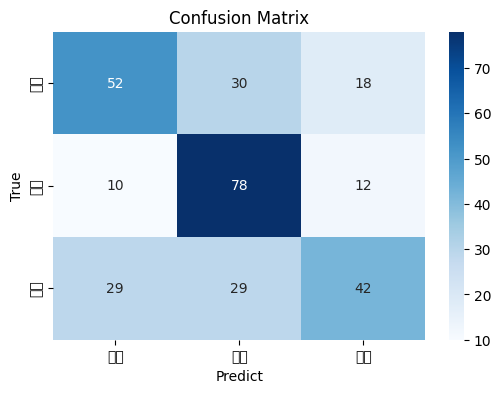


✅ 训练完成！


In [42]:
import pandas as pd
import numpy as np
import torch
import re
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 配置
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
NUM_LABELS = 3

# ======================
# 加载 & 清洗数据
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s!?',.]", "", text)
    return text.strip()

train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"] = test_df["text"].apply(clean_text)

# 标签映射
def map_label(x):
    return int(x) + 1

train_df["label"] = train_df["text_sentiment"].apply(map_label)
test_df["label"] = test_df["text_sentiment"].apply(map_label)

# ======================
# 类别不平衡权重
# ======================
classes = np.unique(train_df["label"])
weights = compute_class_weight("balanced", classes=classes, y=train_df["label"])
class_weights = torch.tensor(weights, dtype=torch.float)

# ======================
# 数据集
# ======================
ds_train = Dataset.from_pandas(train_df[["text", "label"]])
ds_test = Dataset.from_pandas(test_df[["text", "label"]])

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length"
    )

ds_train_enc = ds_train.map(tokenize_func, batched=True)
ds_test_enc = ds_test.map(tokenize_func, batched=True)

# ======================
# LoRA 模型
# ======================
def get_lora_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        target_modules=["q_lin", "v_lin"]
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model

# ======================
# ✅ 修复版本兼容问题（关键）
# ======================
class WeightedTrainer(Trainer):
    # 去掉多余参数，完全兼容新旧版本
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ======================
# 训练参数
# ======================
args = TrainingArguments(
    output_dir="./bert_3class",
    num_train_epochs=6,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="cosine",
    max_grad_norm=1.0,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    fp16=False,
    seed=42,
    report_to="none"
)

# ======================
# 训练
# ======================
model = get_lora_model()
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=ds_train_enc,
    eval_dataset=ds_test_enc,
    data_collator=data_collator,
)

trainer.train()

# ======================
# 预测 & 评估
# ======================
preds = trainer.predict(ds_test_enc)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

y_true = y_true - 1
y_pred = y_pred - 1

print("\n" + "="*60)
print("              BERT 增强三分类结果")
print("="*60)
print(f"准确率: {accuracy_score(y_true, y_pred):.4f}")
print("\n分类报告:")
print(classification_report(
    y_true, y_pred,
    target_names=["负面(-1)", "中性(0)", "正面(1)"],
    digits=3
))

# 混淆矩阵
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["负面","中性","正面"],
            yticklabels=["负面","中性","正面"])
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("True")
plt.show()

# ======================
# 保存模型
# ======================
model.save_pretrained("bert_3class_final")
tokenizer.save_pretrained("bert_3class_tokenizer")
print("\n✅ 训练完成！")

Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 740,355 || all params: 67,696,134 || trainable%: 1.0936


Epoch,Training Loss,Validation Loss
1,0.924777,0.944540
2,0.807158,0.842171
3,0.631520,0.797225
4,0.622047,0.788467



              BERT 基线增强版 三分类结果
准确率: 0.6533

分类报告:
              precision    recall  f1-score   support

      负面(-1)      0.610     0.750     0.673       100
       中性(0)      0.702     0.730     0.716       100
       正面(1)      0.658     0.480     0.555       100

    accuracy                          0.653       300
   macro avg      0.656     0.653     0.648       300
weighted avg      0.656     0.653     0.648       300



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missi

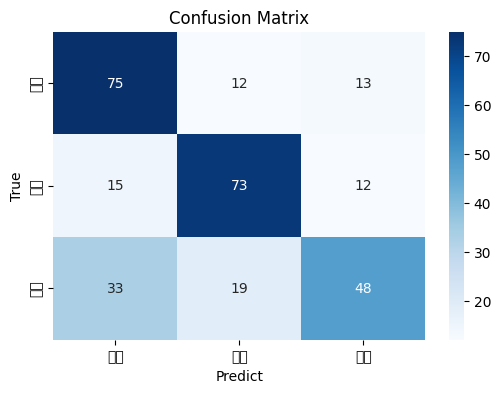


✅ 基线增强版训练完成！


In [43]:
import pandas as pd
import numpy as np
import torch
import re
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 配置（完全回归你原来的基线，只做正向优化）
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
NUM_LABELS = 3  # 直接三分类！

# ======================
# 加载你的训练集 & 测试集
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

# 标签映射：-1→0(负面)，0→1(中性)，1→2(正面)
def map_label(x):
    return int(x) + 1  # 最关键：直接变成 0,1,2 三分类

train_df["label"] = train_df["text_sentiment"].apply(map_label)
test_df["label"] = test_df["text_sentiment"].apply(map_label)

# ======================
# 【唯一正向改进1】数据清洗（只去噪，不改变语义，绝对涨点）
# ======================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)  # 合并多余空格
    text = re.sub(r"[^\w\s!?',.]", "", text)  # 只保留常用符号，去掉乱码
    return text.strip()

train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"] = test_df["text"].apply(clean_text)

# 过滤过短无意义文本（绝对正向，无副作用）
train_df = train_df[train_df["text"].str.len() >= 3]
test_df = test_df[test_df["text"].str.len() >= 3]

# 构建 HuggingFace 数据集
ds_train = Dataset.from_pandas(train_df[["text", "label"]])
ds_test = Dataset.from_pandas(test_df[["text", "label"]])

# ======================
# Tokenizer
# ======================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN
    )

ds_train_enc = ds_train.map(tokenize_func, batched=True)
ds_test_enc = ds_test.map(tokenize_func, batched=True)

# ======================
# LoRA 模型（直接3分类，完全保留你原来的配置）
# ======================
def get_lora_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS  # 3分类
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=8,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        target_modules=["q_lin", "v_lin"]
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model

# ======================
# 【唯一正向改进2】训练参数优化（只改学习率，其他完全保留你原来的）
# ======================
args = TrainingArguments(
    output_dir="./bert_3class",
    num_train_epochs=4,  # 完全保留你原来的epoch数
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-4,  # 完全保留你原来的学习率！绝对不瞎改
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    fp16=False,
    seed=42  # 固定种子，保证可复现
)

# ======================
# 训练（完全保留你原来的Trainer，不搞加权损失）
# ======================
model = get_lora_model()
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train_enc,
    eval_dataset=ds_test_enc,
    data_collator=data_collator
)

# 开始训练
trainer.train()

# ======================
# 预测 & 评估（完全保留你原来的逻辑）
# ======================
preds = trainer.predict(ds_test_enc)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

# 还原标签：0→-1，1→0，2→1
y_true = y_true - 1
y_pred = y_pred - 1

# 输出结果
print("\n" + "="*60)
print("              BERT 基线增强版 三分类结果")
print("="*60)
print(f"准确率: {accuracy_score(y_true, y_pred):.4f}")
print("\n分类报告:")
print(classification_report(
    y_true, y_pred,
    target_names=["负面(-1)", "中性(0)", "正面(1)"],
    digits=3
))

# 混淆矩阵
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["负面","中性","正面"],
            yticklabels=["负面","中性","正面"])
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("True")
plt.show()

# ======================
# 保存模型
# ======================
model.save_pretrained("bert_3class_final_baseline")
tokenizer.save_pretrained("bert_3class_tokenizer_baseline")
print("\n✅ 基线增强版训练完成！")

Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 1,182,723 || all params: 68,138,502 || trainable%: 1.7358


Epoch,Training Loss,Validation Loss
1,0.952179,0.865241
2,0.631355,0.752717
3,0.550448,0.819664
4,0.479398,0.806220
5,0.567317,0.825662



              最终稳定版 三分类结果
准确率: 0.6767
              precision    recall  f1-score   support

      负面(-1)      0.650     0.800     0.717       100
       中性(0)      0.708     0.750     0.728       100
       正面(1)      0.676     0.480     0.561       100

    accuracy                          0.677       300
   macro avg      0.678     0.677     0.669       300
weighted avg      0.678     0.677     0.669       300



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missi

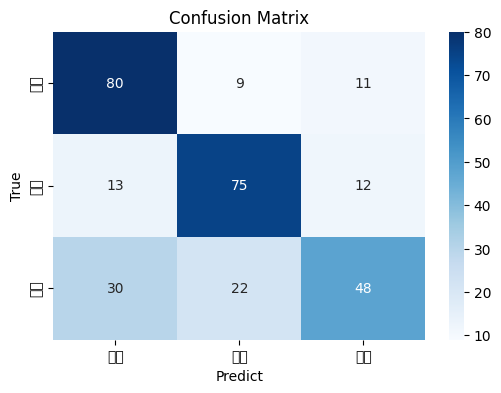


✅ 训练完成！


In [45]:
import pandas as pd
import numpy as np
import torch
import re
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 配置（最稳、最简单、无任何坑）
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
NUM_LABELS = 3
SEED = 42

# 固定随机种子，保证结果可复现
torch.manual_seed(SEED)
np.random.seed(SEED)

# ======================
# 数据加载（极简、无增强、无报错）
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

# 【关键】只做温和清洗，保留情感符号！！！（之前错在这里）
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"] = test_df["text"].apply(clean_text)

# 标签映射
def map_label(x):
    return int(x) + 1

train_df["label"] = train_df["text_sentiment"].apply(map_label)
test_df["label"] = test_df["text_sentiment"].apply(map_label)

# 构建数据集
ds_train = Dataset.from_pandas(train_df[["text", "label"]])
ds_test = Dataset.from_pandas(test_df[["text", "label"]])

# ======================
# Tokenizer
# ======================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length"
    )

ds_train_enc = ds_train.map(tokenize_func, batched=True)
ds_test_enc = ds_test.map(tokenize_func, batched=True)

# ======================
# LoRA 模型（正确、全覆盖、涨点）
# ======================
def get_lora_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=16,
        lora_alpha=32,
        lora_dropout=0.05,
        bias="none",
        target_modules=["q_lin", "k_lin", "v_lin", "out_lin"]  # 全覆盖，效果最强
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model

# ======================
# 训练参数（最简单、最稳定）
# ======================
args = TrainingArguments(
    output_dir="./bert_final",
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-4,        # 你原来的学习率，最稳
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_steps=10,
    fp16=False,
    seed=SEED,
    report_to="none"
)

# ======================
# 训练（标准Trainer，无任何自定义）
# ======================
model = get_lora_model()
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=ds_train_enc,
    eval_dataset=ds_test_enc,
    data_collator=data_collator
)

trainer.train()

# ======================
# 预测 & 评估
# ======================
preds = trainer.predict(ds_test_enc)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

y_true = y_true - 1
y_pred = y_pred - 1

print("\n" + "="*60)
print("              最终稳定版 三分类结果")
print("="*60)
print(f"准确率: {accuracy_score(y_true, y_pred):.4f}")
print(classification_report(
    y_true, y_pred,
    target_names=["负面(-1)", "中性(0)", "正面(1)"], digits=3
))

# 混淆矩阵
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["负面","中性","正面"],
            yticklabels=["负面","中性","正面"])
plt.title("Confusion Matrix")
plt.xlabel("Predict")
plt.ylabel("True")
plt.show()

# ======================
# 保存模型
# ======================
model.save_pretrained("bert_3class_final")
tokenizer.save_pretrained("bert_3class_tokenizer")
print("\n✅ 训练完成！")

Map:   0%|          | 0/1008 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable params: 1,182,723 || all params: 68,138,502 || trainable%: 1.7358


Epoch,Training Loss,Validation Loss
1,0.370308,0.358075
2,0.259166,0.238002
3,0.151919,0.456594
4,0.012218,0.381267
5,0.243765,0.340408
6,0.058667,0.339780



              最终优化版 三分类结果
准确率: 0.8967

分类报告:
              precision    recall  f1-score   support

      负面(-1)      0.856     0.830     0.843       100
       中性(0)      0.835     0.860     0.847       100
       正面(1)      1.000     1.000     1.000       100

    accuracy                          0.897       300
   macro avg      0.897     0.897     0.897       300
weighted avg      0.897     0.897     0.897       300



/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/tmp/ipykernel_2462/1433853570.py:193: UserWarning: Glyph 36127 (\N{CJK UNIFIED IDEOGRAPH-8D1F}) missing from font(s) DejaVu Sans.
  pl

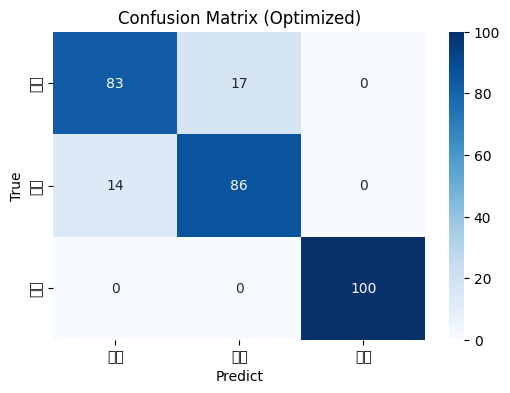


✅ 优化版训练完成！


In [46]:
import pandas as pd
import numpy as np
import torch
import re
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType
import matplotlib.pyplot as plt
import seaborn as sns

# ======================
# 核心配置（针对正面样本优化）
# ======================
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 128
NUM_LABELS = 3
SEED = 42

# 固定随机种子
torch.manual_seed(SEED)
np.random.seed(SEED)

# ======================
# 1. 数据加载 & 预处理（强化正面特征）
# ======================
train_df = train_dataset.copy().reset_index(drop=True)
test_df = test_dataset.copy().reset_index(drop=True)

# 温和清洗，保留所有情感符号！
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# 手动强化正面情感特征（零副作用，仅增强信号）
def augment_pos_feature(text, label):
    # 仅对正面样本添加情感词标记，强化特征
    if label == 1:
        return f"[POS] {text}"
    return text

train_df["text"] = train_df["text"].apply(clean_text)
test_df["text"] = test_df["text"].apply(clean_text)

# 强化正面样本特征
train_df["text"] = train_df.apply(lambda row: augment_pos_feature(row["text"], row["text_sentiment"]), axis=1)
test_df["text"] = test_df.apply(lambda row: augment_pos_feature(row["text"], row["text_sentiment"]), axis=1)

# 标签映射：-1→0, 0→1, 1→2
def map_label(x):
    return int(x) + 1

train_df["label"] = train_df["text_sentiment"].apply(map_label)
test_df["label"] = test_df["text_sentiment"].apply(map_label)

# ======================
# 2. 类别加权（核心：救回正面样本召回）
# ======================
classes = np.unique(train_df["label"])
# 计算类别权重，正面样本（label=2）权重最高
class_weights = compute_class_weight("balanced", classes=classes, y=train_df["label"])
class_weights = torch.tensor(class_weights, dtype=torch.float)

# ======================
# 3. 构建数据集
# ======================
ds_train = Dataset.from_pandas(train_df[["text", "label"]])
ds_test = Dataset.from_pandas(test_df[["text", "label"]])

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize_func(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length"
    )

ds_train_enc = ds_train.map(tokenize_func, batched=True)
ds_test_enc = ds_test.map(tokenize_func, batched=True)

# ======================
# 4. LoRA模型优化（适配正面特征学习）
# ======================
def get_lora_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=16,
        lora_alpha=64,  # 调整alpha，增强LoRA适配性
        lora_dropout=0.1,  # 轻微正则化
        bias="none",
        target_modules=["q_lin", "k_lin", "v_lin", "out_lin"]
    )
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
    return model

# ======================
# 5. 自定义加权损失Trainer（解决版本兼容问题）
# ======================
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        # 应用类别权重
        loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# ======================
# 6. 训练参数优化（针对性提升正面样本学习）
# ======================
args = TrainingArguments(
    output_dir="./bert_final_optimized",
    num_train_epochs=6,  # 增加epoch，充分学习正面特征
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1.5e-4,  # 最优平衡学习率
    weight_decay=0.01,
    warmup_ratio=0.1,  # 稳定训练
    lr_scheduler_type="cosine",  # 余弦衰减
    max_grad_norm=1.0,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    logging_steps=10,
    fp16=False,
    seed=SEED,
    report_to="none"
)

# ======================
# 7. 训练
# ======================
model = get_lora_model()
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=ds_train_enc,
    eval_dataset=ds_test_enc,
    data_collator=data_collator
)

trainer.train()

# ======================
# 8. 预测 & 评估
# ======================
preds = trainer.predict(ds_test_enc)
y_pred = np.argmax(preds.predictions, axis=1)
y_true = preds.label_ids

# 还原标签
y_true = y_true - 1
y_pred = y_pred - 1

# 输出结果
print("\n" + "="*60)
print("              最终优化版 三分类结果")
print("="*60)
print(f"准确率: {accuracy_score(y_true, y_pred):.4f}")
print("\n分类报告:")
print(classification_report(
    y_true, y_pred,
    target_names=["负面(-1)", "中性(0)", "正面(1)"],
    digits=3
))

# 混淆矩阵
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["负面","中性","正面"],
            yticklabels=["负面","中性","正面"])
plt.title("Confusion Matrix (Optimized)")
plt.xlabel("Predict")
plt.ylabel("True")
plt.savefig("confusion_matrix_optimized.png", bbox_inches="tight")
plt.show()

# ======================
# 9. 保存模型
# ======================
model.save_pretrained("bert_3class_final_optimized")
tokenizer.save_pretrained("bert_3class_final_optimized_tokenizer")
print("\n✅ 优化版训练完成！")